You can check the current progress during the class from this link:

FASS G022:
https://colab.research.google.com/drive/1lxgj2IFthKBhtx1u5SQzczcvDpiDSa0l?usp=sharing

FENS L045:
https://colab.research.google.com/drive/1xtyuOur9_yJEP5mcM3IpjRwuogEtjQbl?usp=sharing

Neural Network From Scratch
======================================================
Part 1.
======================================================
A step-by-step implementation of a 1-hidden-layer ANN with backpropagation


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

We'll build a neural network with:
- Input layer: n features
- Hidden layer: m neurons (1 hidden layer)
- Output layer: 1 neuron (binary classification)

Architecture:
    Input (X) → Hidden Layer (with activation) → Output Layer (with activation) → Prediction

In [ ]:
def sigmoid(z):
    """
    Sigmoid activation function: σ(z) = 1 / (1 + e^(-z))
    Maps any value to (0, 1)
    """
    #TODO
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """
    Derivative of sigmoid: σ'(z) = σ(z) * (1 - σ(z))
    This is used in backpropagation
    """
    s = sigmoid(z)
    #TODO
    return s * (1 - s)

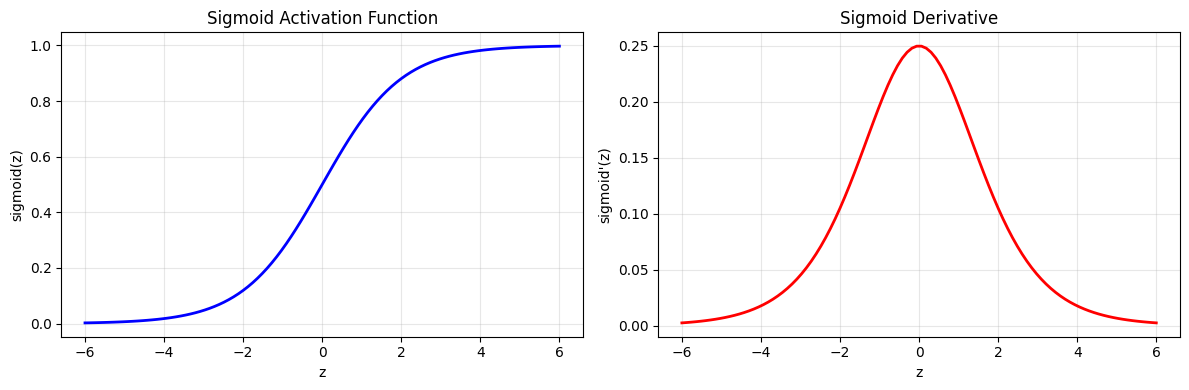

In [ ]:
# Visualize activation functions
z = np.linspace(-6, 6, 100)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid(z), 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Activation Function')

plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_derivative(z), 'r-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('z')
plt.ylabel("sigmoid'(z)")
plt.title('Sigmoid Derivative')

plt.tight_layout()
plt.show()

In [ ]:
class NeuralNetwork:

    def __init__(self, input_size, hidden_size, output_size):
        """
        PART 3: Initialize the neural network with random weights

        Parameters:
        - input_size: number of input features
        - hidden_size: number of neurons in hidden layer
        - output_size: number of output neurons (1 for binary classification)
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Initialize weights with small random values
        # W1: weights from input to hidden layer (hidden_size × input_size)
        # b1: biases for hidden layer (hidden_size × 1)

        #TODO
        self.W1 = np.random.randn(hidden_size, input_size) * 0.1
        self.b1 = np.zeros((hidden_size, 1))

        # W2: weights from hidden to output layer (output_size × hidden_size)
        # b2: biases for output layer (output_size × 1)

        #TODO
        self.W2 = np.random.randn(output_size, hidden_size) * 0.1
        self.b2 = np.zeros((output_size, 1))


        print(f"Network initialized:")
        print(f"  Input layer: {input_size} neurons")
        print(f"  Hidden layer: {hidden_size} neurons")
        print(f"  Output layer: {output_size} neuron(s)")
        print(f"\nWeight matrices:")
        print(f"  W1 shape: {self.W1.shape}")
        print(f"  b1 shape: {self.b1.shape}")
        print(f"  W2 shape: {self.W2.shape}")
        print(f"  b2 shape: {self.b2.shape}")

    # ========================================================================
    # PART 4: Forward Propagation
    # ========================================================================

    def forward_propagation(self, X):
        """
        Forward pass through the network

        Steps:
        1. Calculate hidden layer: Z1 = W1·X + b1
        2. Apply activation: A1 = sigmoid(Z1)
        3. Calculate output layer: Z2 = W2·A1 + b2
        4. Apply activation: A2 = sigmoid(Z2)

        Parameters:
        - X: input data (input_size × m) where m is number of examples

        Returns:
        - A2: final output (predictions)
        - cache: intermediate values needed for backprop
        """
        # Hidden layer

        #TODO
        Z1 = np.dot(self.W1, X) + self.b1                     # Linear combination
        A1 = sigmoid(Z1)                     # Activation

        # Output layer
        Z2 = np.dot(self.W2, A1) + self.b2                   # Linear combination
        A2 = sigmoid(Z2)                     # Activation (final prediction)

        # Store values for backpropagation
        cache = {
            'Z1': Z1, 'A1': A1,
            'Z2': Z2, 'A2': A2,
            'X': X
        }

        return A2, cache

    # ========================================================================
    # PART 5: Cost Function
    # ========================================================================

    def compute_cost(self, A2, Y):
        """
        Compute binary cross-entropy cost

        Formula: J = -1/m * Σ[y*log(a) + (1-y)*log(1-a)]

        Parameters:
        - A2: predictions (output_size × m)
        - Y: true labels (output_size × m)

        Returns:
        - cost: scalar value
        """
        m = Y.shape[1]  # number of examples

        # Binary cross-entropy loss
        logprobs = np.multiply(Y, np.log(A2)) + np.multiply(1 - Y, np.log(1 - A2))
        cost = -np.sum(logprobs) / m

        return float(cost)

    # ========================================================================
    # PART 6: Backward Propagation (The Heart of Learning!)
    # ========================================================================

    def backward_propagation(self, cache, Y):
        """
        Backward pass - compute gradients using chain rule

        Mathematical Derivation:
        ------------------------
        Cost function: J = -1/m * Σ[y*log(a₂) + (1-y)*log(1-a₂)]

        Output layer gradients:
        - dJ/dZ2 = A2 - Y  (derivative of cost w.r.t. Z2)
        - dJ/dW2 = dZ2 · A1ᵀ / m
        - dJ/db2 = sum(dZ2) / m

        Hidden layer gradients (chain rule):
        - dJ/dA1 = W2ᵀ · dZ2
        - dJ/dZ1 = dA1 ⊙ sigmoid'(Z1)  (⊙ is element-wise multiplication)
        - dJ/dW1 = dZ1 · Xᵀ / m
        - dJ/db1 = sum(dZ1) / m

        Parameters:
        - cache: values from forward propagation
        - Y: true labels

        Returns:
        - grads: dictionary of gradients
        """
        m = Y.shape[1]  # number of examples

        # Retrieve cached values
        X = cache['X']
        A1 = cache['A1']
        A2 = cache['A2']
        Z1 = cache['Z1']

        # Output layer gradients

        #TODO
        dZ2 = A2 - Y  # Derivative of cost w.r.t. Z2
        dW2 = np.dot(dZ2, A1.T) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m

        # Hidden layer gradients (chain rule!)
        dA1 = np.dot(self.W2.T, dZ2)  # Backprop to hidden layer
        dZ1 = dA1 * sigmoid_derivative(Z1)  # Apply derivative of activation
        dW1 = np.dot(dZ1, X.T) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m

        grads = {
            'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2
        }

        return grads

    # ========================================================================
    # PART 7: Update Parameters (Gradient Descent)
    # ========================================================================

    def update_parameters(self, grads, learning_rate):
        """
        Update parameters using gradient descent

        Formula: θ = θ - α * dJ/dθ
        where α is the learning rate

        Parameters:
        - grads: dictionary of gradients
        - learning_rate: step size for updates
        """

        #TODO
        self.W1 -= learning_rate * grads['dW1']
        self.b1 -= learning_rate * grads['db1']
        self.W2 -= learning_rate * grads['dW2']
        self.b2 -= learning_rate * grads['db2']

    # ========================================================================
    # PART 8: Training Loop
    # ========================================================================

    def train(self, X, Y, learning_rate=0.1, num_iterations=10000, print_cost=True):
        """
        Train the neural network

        Parameters:
        - X: training data (input_size × m)
        - Y: labels (output_size × m)
        - learning_rate: learning rate for gradient descent
        - num_iterations: number of training iterations
        - print_cost: whether to print cost during training

        Returns:
        - costs: list of costs during training
        """
        costs = []

        #TODO

        for i in range(num_iterations):
            # Forward propagation
            A2, cache = self.forward_propagation(X)

            # Compute cost
            cost = self.compute_cost(A2, Y)

            # Backward propagation
            grads = self.backward_propagation(cache, Y)

            # Update parameters
            self.update_parameters(grads, learning_rate)

            # Record cost
            if i % 100 == 0:
                costs.append(cost)
                if print_cost and i % 1000 == 0:
                    print(f"Cost after iteration {i}: {cost:.6f}")

        return costs

    # ========================================================================
    # PART 9: Prediction
    # ========================================================================

    def predict(self, X):
        """
        Make predictions on new data

        Parameters:
        - X: input data (input_size × m)

        Returns:
        - predictions: binary predictions (0 or 1)
        """
        A2, _ = self.forward_propagation(X)
        predictions = (A2 > 0.5).astype(int)
        return predictions

Part 2. Train the model with 3 different datasets
======================================================


# **2.1 The XOR problem is a classic non-linearly separable problem:**
- Input: two binary values
- Output: 1 if inputs are different, 0 if same

Truth table:

  X1  X2  |  Y

  0   0   |  0

  0   1   |  1

  1   0   |  1

  1   1   |  0




This cannot be solved with a single layer (perceptron)!
We need a hidden layer to learn this pattern.

In [ ]:
# XOR dataset
X_train = np.array([[0, 0, 1, 1],
                    [0, 1, 0, 1]])
Y_train = np.array([[0, 1, 1, 0]])

print(f"Training data shape: {X_train.shape}")
print(f"Labels shape: {Y_train.shape}")
print(f"\nX_train:\n{X_train}")
print(f"\nY_train:\n{Y_train}")

Training data shape: (2, 4)
Labels shape: (1, 4)

X_train:
[[0 0 1 1]
 [0 1 0 1]]

Y_train:
[[0 1 1 0]]


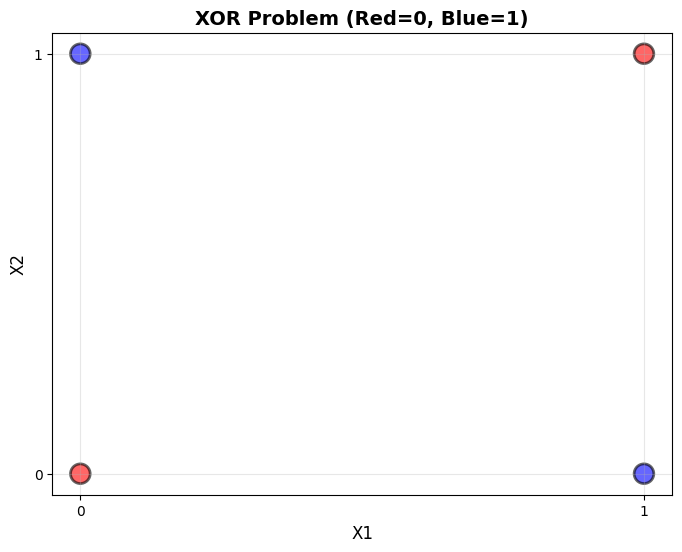

In [ ]:
# Visualize the dataset
plt.figure(figsize=(8, 6))
colors = ['red' if y == 0 else 'blue' for y in Y_train[0]]
plt.scatter(X_train[0, :], X_train[1, :], c=colors, s=200, alpha=0.6, edgecolors='black', linewidth=2)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('XOR Problem (Red=0, Blue=1)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()

Network initialized:
  Input layer: 2 neurons
  Hidden layer: 4 neurons
  Output layer: 1 neuron(s)

Weight matrices:
  W1 shape: (4, 2)
  b1 shape: (4, 1)
  W2 shape: (1, 4)
  b2 shape: (1, 1)
Cost after iteration 0: 0.693375
Cost after iteration 1000: 0.693145
Cost after iteration 2000: 0.693136
Cost after iteration 3000: 0.672452
Cost after iteration 4000: 0.012332
Cost after iteration 5000: 0.004757
Cost after iteration 6000: 0.002894
Cost after iteration 7000: 0.002067
Cost after iteration 8000: 0.001604
Cost after iteration 9000: 0.001308
Cost after iteration 10000: 0.001103
Cost after iteration 11000: 0.000953
Cost after iteration 12000: 0.000838
Cost after iteration 13000: 0.000748
Cost after iteration 14000: 0.000675
Cost after iteration 15000: 0.000615
Cost after iteration 16000: 0.000565
Cost after iteration 17000: 0.000522
Cost after iteration 18000: 0.000485
Cost after iteration 19000: 0.000453
Cost after iteration 20000: 0.000425
Cost after iteration 21000: 0.000400
Cost 

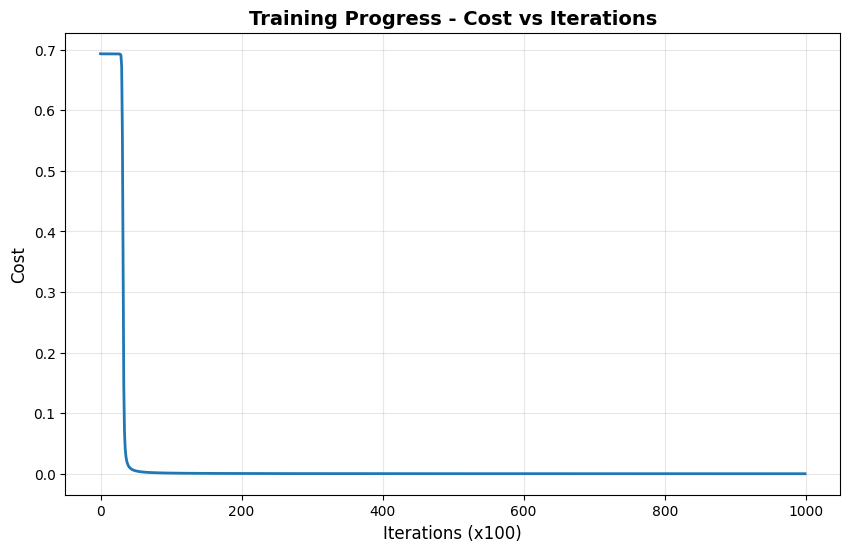

In [ ]:
# Create and train the network
#With input size of 2 and output size of 1, test different hidden sizes

#TODO
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)
costs = nn.train(X_train, Y_train, learning_rate=1.0, num_iterations=100000, print_cost=True)

# Plot training progress
plt.figure(figsize=(10, 6))
plt.plot(costs, linewidth=2)
plt.xlabel('Iterations (x100)', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Training Progress - Cost vs Iterations', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Make predictions
#TODO
predictions = nn.predict(X_train)

print("\nFinal Predictions:")
print("=" * 40)
for i in range(X_train.shape[1]):
    x1, x2 = X_train[:, i]
    true_label = Y_train[0, i]
    pred_label = predictions[0, i]
    print(f"Input: [{x1}, {x2}] → Prediction: {pred_label}, True: {true_label} {'✓' if pred_label == true_label else '✗'}")

# Calculate accuracy
accuracy = np.mean(predictions == Y_train) * 100
print(f"\nTraining Accuracy: {accuracy:.2f}%")


Final Predictions:
Input: [0, 0] → Prediction: 0, True: 0 ✓
Input: [0, 1] → Prediction: 1, True: 1 ✓
Input: [1, 0] → Prediction: 1, True: 1 ✓
Input: [1, 1] → Prediction: 0, True: 0 ✓

Training Accuracy: 100.00%


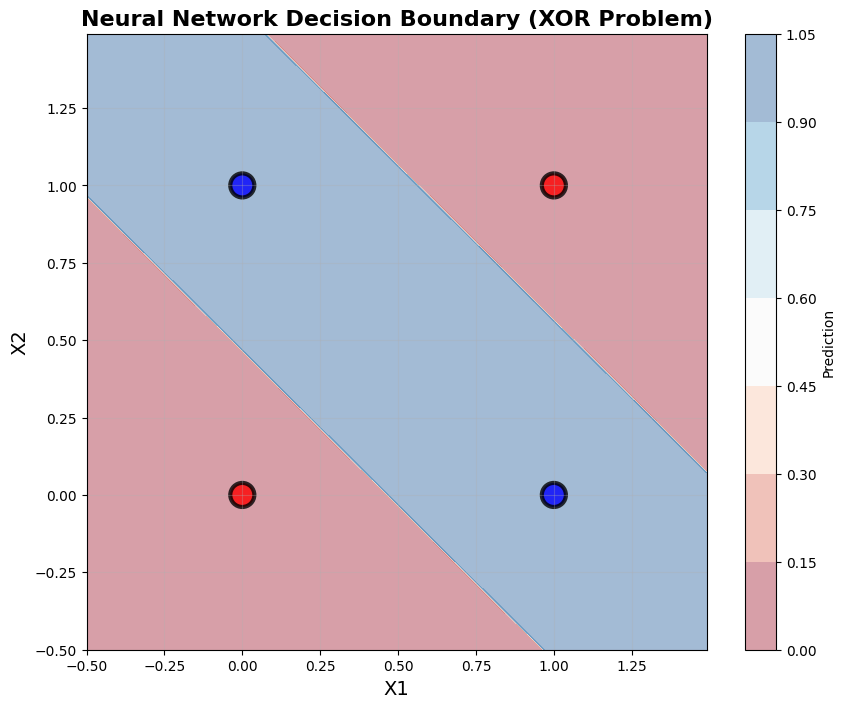

In [ ]:


# Create a mesh grid
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
h = 0.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Make predictions on the mesh
Z = nn.predict(np.c_[xx.ravel(), yy.ravel()].T)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
plt.colorbar(label='Prediction')

# Plot training points
colors = ['red' if y == 0 else 'blue' for y in Y_train[0]]
plt.scatter(X_train[0, :], X_train[1, :], c=colors, s=300, alpha=0.8, edgecolors='black', linewidth=3)

plt.xlabel('X1', fontsize=14)
plt.ylabel('X2', fontsize=14)
plt.title('Neural Network Decision Boundary (XOR Problem)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# **2.2 Circular Dataset**


Circular Dataset:
  X shape: (2, 1000) (2 features × 200 samples)
  Y shape: (1, 1000)
  Class 0 (outside): 725 samples
  Class 1 (inside): 275 samples


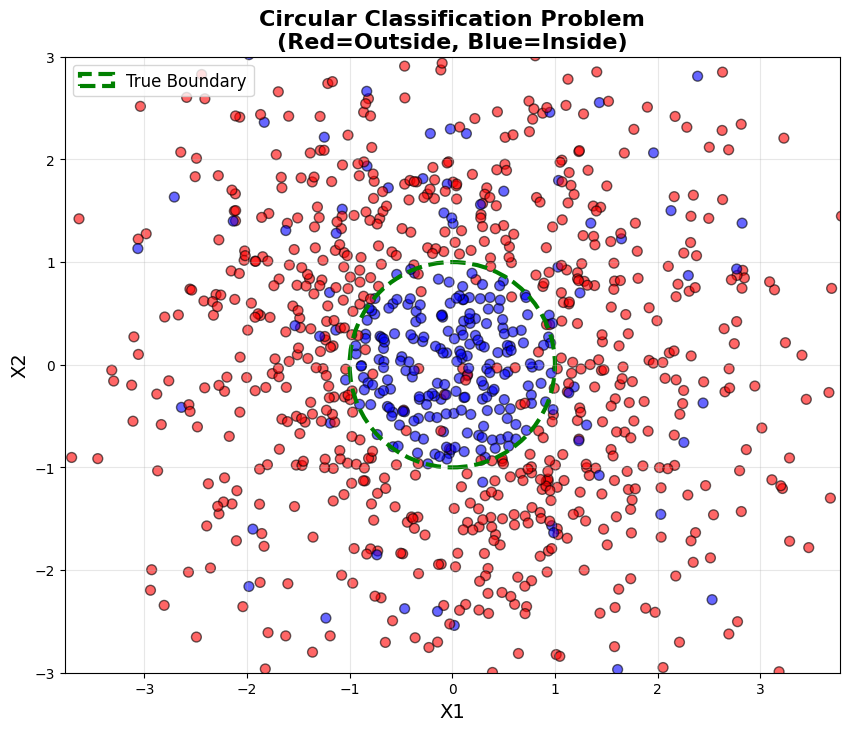

In [ ]:
# Generate circular dataset

def generate_circular_data(n_samples=200, noise=0.1):
    """
    Generate circular classification dataset
    - Inner circle: class 1
    - Outer region: class 0
    """
    # Generate random points
    X = np.random.randn(2, n_samples) * 1.5

    # Calculate distance from origin
    distances = np.sqrt(X[0, :]**2 + X[1, :]**2)

    # Label based on distance (radius = 1.0)
    Y = (distances < 1.0).astype(int).reshape(1, -1)

    # Add some noise to make it harder
    noise_samples = int(n_samples * noise)
    noise_indices = np.random.choice(n_samples, noise_samples, replace=False)
    Y[0, noise_indices] = 1 - Y[0, noise_indices]  # Flip labels

    return X, Y

# Generate dataset
X_circle, Y_circle = generate_circular_data(n_samples=1000, noise=0.1)

print(f"\nCircular Dataset:")
print(f"  X shape: {X_circle.shape} (2 features × 200 samples)")
print(f"  Y shape: {Y_circle.shape}")
print(f"  Class 0 (outside): {np.sum(Y_circle == 0)} samples")
print(f"  Class 1 (inside): {np.sum(Y_circle == 1)} samples")

# Visualize the circular dataset
plt.figure(figsize=(10, 8))
colors = ['red' if y == 0 else 'blue' for y in Y_circle[0]]
plt.scatter(X_circle[0, :], X_circle[1, :], c=colors, s=50, alpha=0.6, edgecolors='black', linewidth=1)

# Draw the true boundary circle
circle = plt.Circle((0, 0), 1.0, color='green', fill=False, linewidth=3, linestyle='--', label='True Boundary')
plt.gca().add_patch(circle)

plt.xlabel('X1', fontsize=14)
plt.ylabel('X2', fontsize=14)
plt.title('Circular Classification Problem\n(Red=Outside, Blue=Inside)', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()


Creating a larger network for the circular problem...
Network initialized:
  Input layer: 2 neurons
  Hidden layer: 10 neurons
  Output layer: 1 neuron(s)

Weight matrices:
  W1 shape: (10, 2)
  b1 shape: (10, 1)
  W2 shape: (1, 10)
  b2 shape: (1, 1)

Training... (this may take a moment)
Cost after iteration 0: 0.678091
Cost after iteration 1000: 0.588125
Cost after iteration 2000: 0.588057
Cost after iteration 3000: 0.583504
Cost after iteration 4000: 0.407693
Cost after iteration 5000: 0.377237
Cost after iteration 6000: 0.374998
Cost after iteration 7000: 0.374327
Cost after iteration 8000: 0.373896
Cost after iteration 9000: 0.373516
Cost after iteration 10000: 0.373135
Cost after iteration 11000: 0.372665
Cost after iteration 12000: 0.372074
Cost after iteration 13000: 0.371380
Cost after iteration 14000: 0.370538


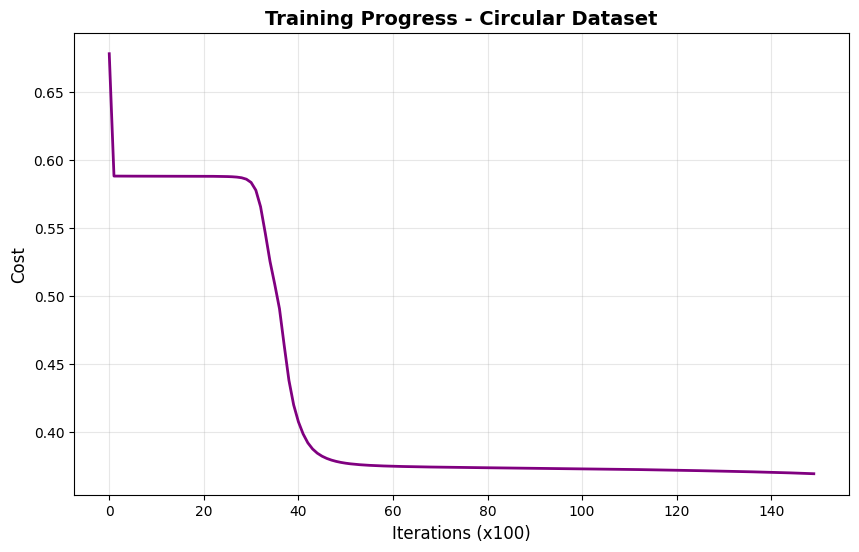


Training completed!


In [ ]:
# Create a new network with more hidden neurons for this complex task
print("\nCreating a larger network for the circular problem...")
nn_circle = NeuralNetwork(input_size=2, hidden_size=10, output_size=1)

# Train the network
print("\nTraining... (this may take a moment)")
costs_circle = nn_circle.train(X_circle, Y_circle, learning_rate=0.5, num_iterations=15000, print_cost=True)

# Plot training progress
plt.figure(figsize=(10, 6))
plt.plot(costs_circle, linewidth=2, color='purple')
plt.xlabel('Iterations (x100)', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Training Progress - Circular Dataset', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("\nTraining completed!")

/tmp/ipython-input-1895176204.py:43: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_circle[0, ~correct], X_circle[1, ~correct], c=[colors_pred[i] for i in range(len(correct)) if not correct[i]],



Training Accuracy: 86.50%

Confusion Matrix:
  True Positives (inside → inside): 177
  True Negatives (outside → outside): 688
  False Positives (outside → inside): 37
  False Negatives (inside → outside): 98


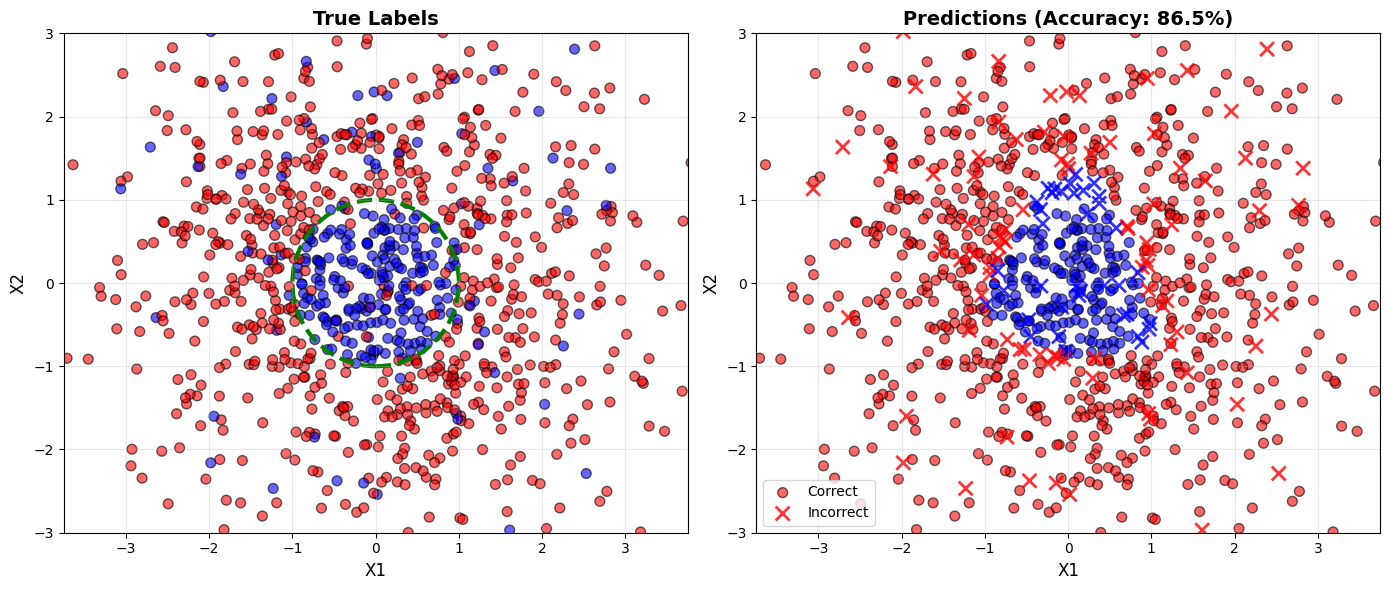

In [ ]:
predictions_circle = nn_circle.predict(X_circle)

# Calculate accuracy
accuracy_circle = np.mean(predictions_circle == Y_circle) * 100
print(f"\nTraining Accuracy: {accuracy_circle:.2f}%")

# Confusion matrix
true_positives = np.sum((predictions_circle == 1) & (Y_circle == 1))
true_negatives = np.sum((predictions_circle == 0) & (Y_circle == 0))
false_positives = np.sum((predictions_circle == 1) & (Y_circle == 0))
false_negatives = np.sum((predictions_circle == 0) & (Y_circle == 1))

print("\nConfusion Matrix:")
print(f"  True Positives (inside → inside): {true_positives}")
print(f"  True Negatives (outside → outside): {true_negatives}")
print(f"  False Positives (outside → inside): {false_positives}")
print(f"  False Negatives (inside → outside): {false_negatives}")

# Visualize predictions
plt.figure(figsize=(14, 6))

# Subplot 1: True labels
plt.subplot(1, 2, 1)
colors_true = ['red' if y == 0 else 'blue' for y in Y_circle[0]]
plt.scatter(X_circle[0, :], X_circle[1, :], c=colors_true, s=50, alpha=0.6, edgecolors='black', linewidth=1)
circle = plt.Circle((0, 0), 1.0, color='green', fill=False, linewidth=3, linestyle='--')
plt.gca().add_patch(circle)
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title('True Labels', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-3, 3)
plt.ylim(-3, 3)

# Subplot 2: Predictions
plt.subplot(1, 2, 2)
colors_pred = ['red' if y == 0 else 'blue' for y in predictions_circle[0]]
# Mark incorrect predictions with X
correct = (predictions_circle == Y_circle)[0]
plt.scatter(X_circle[0, correct], X_circle[1, correct], c=[colors_pred[i] for i in range(len(correct)) if correct[i]],
            s=50, alpha=0.6, edgecolors='black', linewidth=1, marker='o', label='Correct')
plt.scatter(X_circle[0, ~correct], X_circle[1, ~correct], c=[colors_pred[i] for i in range(len(correct)) if not correct[i]],
            s=100, alpha=0.8, edgecolors='black', linewidth=2, marker='x', label='Incorrect')
plt.xlabel('X1', fontsize=12)
plt.ylabel('X2', fontsize=12)
plt.title(f'Predictions (Accuracy: {accuracy_circle:.1f}%)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.tight_layout()
plt.show()


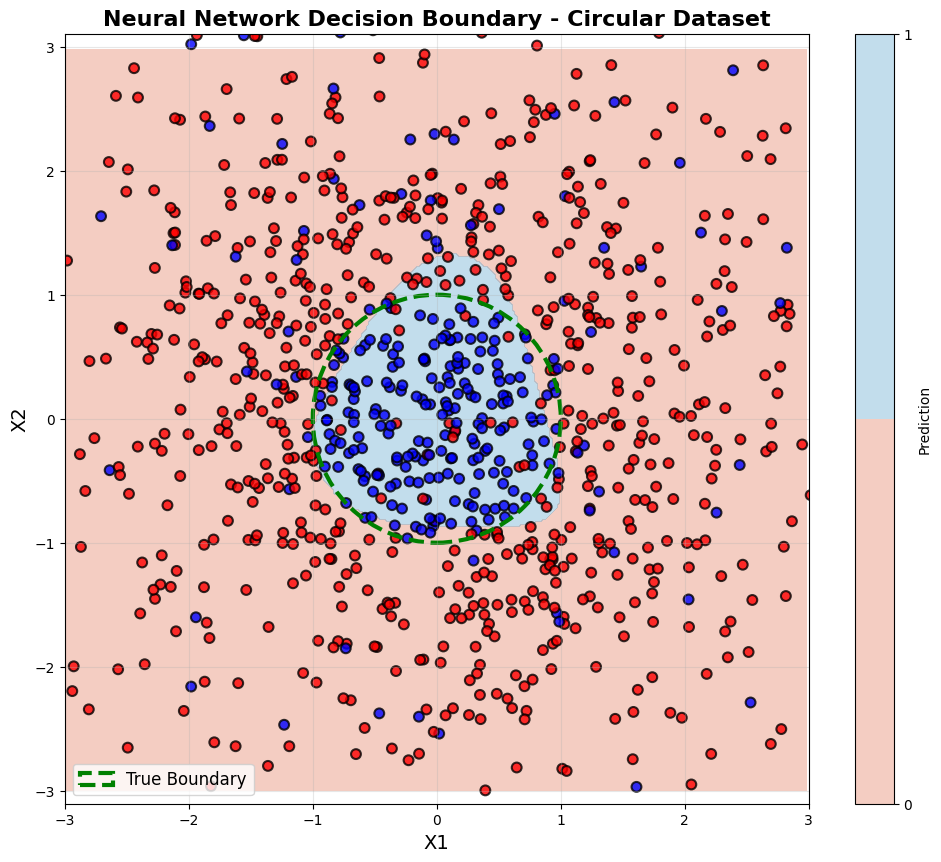

In [ ]:
# Create a mesh grid
x_min, x_max = -3, 3
y_min, y_max = -3, 3
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Make predictions on the mesh
Z_circle = nn_circle.predict(np.c_[xx.ravel(), yy.ravel()].T)
Z_circle = Z_circle.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(12, 10))
plt.contourf(xx, yy, Z_circle, alpha=0.4, cmap='RdBu', levels=1)
plt.colorbar(label='Prediction', ticks=[0, 1])

# Plot training points
colors = ['red' if y == 0 else 'blue' for y in Y_circle[0]]
plt.scatter(X_circle[0, :], X_circle[1, :], c=colors, s=50, alpha=0.8, edgecolors='black', linewidth=1.5)

# Draw true boundary
circle = plt.Circle((0, 0), 1.0, color='green', fill=False, linewidth=3, linestyle='--', label='True Boundary')
plt.gca().add_patch(circle)

plt.xlabel('X1', fontsize=14)
plt.ylabel('X2', fontsize=14)
plt.title('Neural Network Decision Boundary - Circular Dataset', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.show()

# **2.3 Breast Cancer Dataset**

In [ ]:
# Import sklearn to load the dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load the dataset
print("\nLoading dataset from sklearn...")
data = load_breast_cancer()
X_cancer = data.data.T  # Transpose to (features × samples)
Y_cancer = data.target.reshape(1, -1)

print(f"\n✓ Dataset loaded successfully!")
print(f"\nDataset Information:")
print(f"  Total samples: {X_cancer.shape[1]}")
print(f"  Number of features: {X_cancer.shape[0]}")
print(f"  Class 0 (Malignant): {np.sum(Y_cancer == 0)} samples")
print(f"  Class 1 (Benign): {np.sum(Y_cancer == 1)} samples")

print(f"\nFeature names (first 10):")
for i, name in enumerate(data.feature_names[:10]):
    print(f"  {i+1}. {name}")
print(f"  ... and {len(data.feature_names) - 10} more features")

# Normalize the features (important for neural networks!)
print("\nNormalizing features (standardization)...")
scaler = StandardScaler()
X_cancer_normalized = scaler.fit_transform(X_cancer.T).T

# Split into train and test sets
print("Splitting into train (80%) and test (20%) sets...")
X_train_cancer = X_cancer_normalized[:, :int(0.8 * X_cancer.shape[1])]
Y_train_cancer = Y_cancer[:, :int(0.8 * Y_cancer.shape[1])]
X_test_cancer = X_cancer_normalized[:, int(0.8 * X_cancer.shape[1]):]
Y_test_cancer = Y_cancer[:, int(0.8 * Y_cancer.shape[1]):]

print(f"\n✓ Data preparation complete!")
print(f"  Training set: {X_train_cancer.shape[1]} samples")
print(f"  Test set: {X_test_cancer.shape[1]} samples")

# Visualize class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
classes, counts = np.unique(Y_cancer, return_counts=True)
colors_bar = ['red', 'blue']
plt.bar(['Malignant (0)', 'Benign (1)'], counts, color=colors_bar, alpha=0.7, edgecolor='black')
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
# Show mean values of first 5 features
feature_means = X_cancer_normalized[:5, :].mean(axis=1)
plt.barh(data.feature_names[:5], feature_means, color='purple', alpha=0.7, edgecolor='black')
plt.xlabel('Mean Value (normalized)', fontsize=12)
plt.title('Sample Feature Values (First 5)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
print("\nCreating a neural network for the breast cancer dataset...")
nn_cancer = NeuralNetwork(input_size=30, hidden_size=20, output_size=1)

# Train the network
print("\nTraining on real medical data... (this may take a moment)")
costs_cancer = nn_cancer.train(X_train_cancer, Y_train_cancer, learning_rate=0.5, num_iterations=10000, print_cost=True)

# Plot training progress
plt.figure(figsize=(10, 6))
plt.plot(costs_cancer, linewidth=2, color='green')
plt.xlabel('Iterations (x100)', fontsize=12)
plt.ylabel('Cost', fontsize=12)
plt.title('Training Progress - Breast Cancer Dataset', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("\nTraining completed!")

In [ ]:
predictions_train = nn_cancer.predict(X_train_cancer)
accuracy_train = np.mean(predictions_train == Y_train_cancer) * 100

# Make predictions on TEST set (unseen data!)
predictions_test = nn_cancer.predict(X_test_cancer)
accuracy_test = np.mean(predictions_test == Y_test_cancer) * 100

print(f"\n{'='*50}")
print(f"PERFORMANCE METRICS")
print(f"{'='*50}")
print(f"Training Accuracy: {accuracy_train:.2f}%")
print(f"Test Accuracy:     {accuracy_test:.2f}%")
print(f"{'='*50}")

# Confusion matrix for test set
true_positives = np.sum((predictions_test == 1) & (Y_test_cancer == 1))
true_negatives = np.sum((predictions_test == 0) & (Y_test_cancer == 0))
false_positives = np.sum((predictions_test == 1) & (Y_test_cancer == 0))
false_negatives = np.sum((predictions_test == 0) & (Y_test_cancer == 1))

print("\nConfusion Matrix (Test Set):")
print(f"  True Positives (Benign → Benign):       {true_positives}")
print(f"  True Negatives (Malignant → Malignant): {true_negatives}")
print(f"  False Positives (Malignant → Benign):   {false_positives}")
print(f"  False Negatives (Benign → Malignant):   {false_negatives}")

# Calculate additional metrics
if (true_positives + false_negatives) > 0:
    sensitivity = true_positives / (true_positives + false_negatives)
    print(f"\nRecall:               {sensitivity:.2%}")
if (true_positives + false_positives) > 0:
    precision = true_positives / (true_positives + false_positives)
    print(f"Precision:            {precision:.2%}")



# **Part 3. Convnets**

In [ ]:
!pip install torchinfo

In [ ]:
from PIL import Image
import random
import time

import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torch import nn
import torch.nn.functional as F
from torchinfo import summary

In [ ]:
alexnet = models.alexnet(pretrained=True)
print(alexnet)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 96.8MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
summary(alexnet, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [1, 1000]                 --
├─Sequential: 1-1                        [1, 256, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 64, 55, 55]           23,296
│    └─ReLU: 2-2                         [1, 64, 55, 55]           --
│    └─MaxPool2d: 2-3                    [1, 64, 27, 27]           --
│    └─Conv2d: 2-4                       [1, 192, 27, 27]          307,392
│    └─ReLU: 2-5                         [1, 192, 27, 27]          --
│    └─MaxPool2d: 2-6                    [1, 192, 13, 13]          --
│    └─Conv2d: 2-7                       [1, 384, 13, 13]          663,936
│    └─ReLU: 2-8                         [1, 384, 13, 13]          --
│    └─Conv2d: 2-9                       [1, 256, 13, 13]          884,992
│    └─ReLU: 2-10                        [1, 256, 13, 13]          --
│    └─Conv2d: 2-11                      [1, 256, 13, 13]         

In [ ]:
# without using transforms


train_set_without_transform = datasets.CIFAR10(
    root="data",
    download=True,
    train=True
)

test_set_without_transform = datasets.CIFAR10(
    root = "data",
    download = True,
    train = False
)

train_set_without_transform.class_to_idx

100%|██████████| 170M/170M [00:10<00:00, 16.2MB/s]


{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [ ]:
len(train_set_without_transform)

50000

In [ ]:
len(test_set_without_transform)

10000

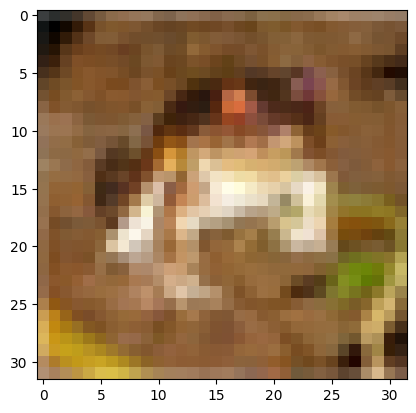

In [ ]:
image_pil, label = train_set_without_transform[0]
plt.imshow(image_pil)


In [ ]:
print(type(image_pil))

<class 'PIL.Image.Image'>


In [ ]:
image_numpy = np.array(image_pil)
print(type(image_numpy))

<class 'numpy.ndarray'>


In [ ]:
print(image_numpy.shape)

(32, 32, 3)


In [ ]:
print(image_numpy.mean())

103.447265625


In [ ]:
print(image_numpy.std())

51.97371837166704


In [ ]:
# converting into torch tensor

totensor = transforms.ToTensor()

image_tensor = totensor(image_pil)


In [ ]:
print(image_tensor.shape)

torch.Size([3, 32, 32])


In [ ]:
print(image_tensor.mean())

tensor(0.4057)


In [ ]:
print(image_tensor.std())

tensor(0.2039)


In [ ]:

# with using transforms


train_set_with_transform = datasets.CIFAR10(
    root="data",
    download=True,
    train=True,
    transform= transforms.ToTensor()
)

test_set_with_transform = datasets.CIFAR10(
    root = "data",
    download = True,
    train = False,
     transform = transforms.ToTensor()
)

<class 'PIL.Image.Image'>


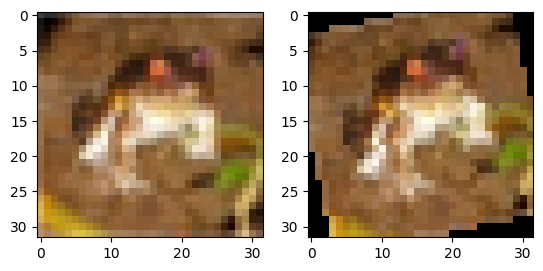

In [ ]:
# How about data augmentation

random_rot = transforms.RandomRotation(degrees=50)
rotated_image = random_rot(image_pil)

print(type(rotated_image))

plt.subplot(1,2,1)
plt.imshow(image_pil) # PIL image

plt.subplot(1,2,2)
plt.imshow(rotated_image)

plt.show()



<class 'PIL.Image.Image'>


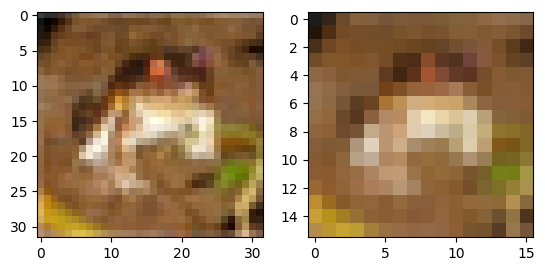

In [ ]:
random_resize = transforms.Resize(size=(16,16))
resized_image = random_resize(image_pil)

print(type(resized_image))

plt.subplot(1,2,1)
plt.imshow(image_pil) # PIL image

plt.subplot(1,2,2)
plt.imshow(resized_image)

plt.show()


<class 'PIL.Image.Image'>
(32, 32)


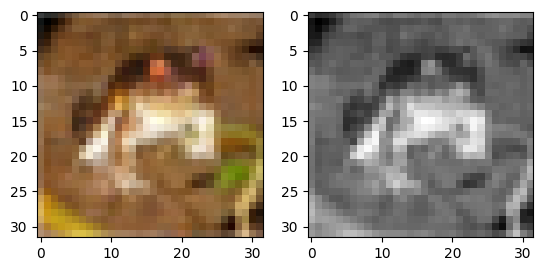

In [ ]:
gray = transforms.Grayscale(num_output_channels=1)
gray_image = gray(image_pil)

print(type(gray_image))
print(np.array(gray_image).shape)

plt.subplot(1,2,1)
plt.imshow(image_pil) # PIL image

plt.subplot(1,2,2)
plt.imshow(gray_image, cmap="gray")

plt.show()


<class 'PIL.Image.Image'>


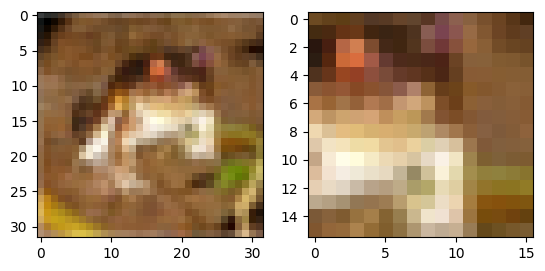

In [ ]:
random_croped = transforms.RandomCrop(size=(16,16))
crop_image = random_croped(image_pil)

print(type(crop_image))

plt.subplot(1,2,1)
plt.imshow(image_pil) # PIL image

plt.subplot(1,2,2)
plt.imshow(crop_image)

plt.show()

In [ ]:
train_ds, val_ds = torch.utils.data.random_split(train_set_with_transform, lengths=[0.8, 0.2])

In [ ]:
len(train_ds)

40000

In [ ]:
len(val_ds)

10000

In [ ]:
train_dl = DataLoader(dataset = train_ds, batch_size=64, shuffle=True, num_workers=6)
val_dl = DataLoader(dataset = val_ds, batch_size=64, shuffle=False, num_workers=6)
test_dl = DataLoader(dataset = test_set_with_transform, batch_size=64, shuffle=False, num_workers=6)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


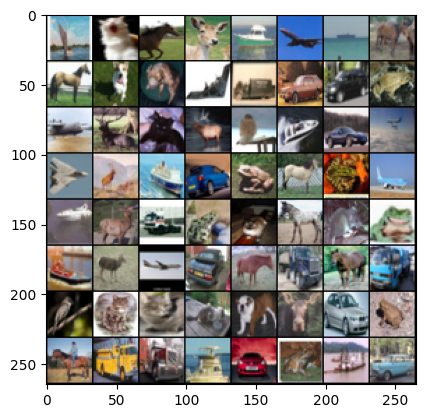

In [ ]:
images, labels = next(iter(train_dl))

outs = torchvision.utils.make_grid(images, padding=1)

plt.imshow(outs.permute(1,2,0))
plt.show()



In [ ]:
print(images.shape) # bs, c, w, h

torch.Size([64, 3, 32, 32])


# **3.1 CNN Basics**

In [ ]:
a = torch.randn(size=(25,)).reshape(5,5)

In [ ]:
a

tensor([[-1.0873, -1.6759,  0.5344, -0.0669, -0.6914],
        [ 0.7181, -0.1879,  0.6393, -2.1285,  0.5496],
        [-2.0111,  0.1135,  0.0058,  0.2783,  0.2402],
        [ 0.3686,  0.7550, -0.1182, -0.1015,  1.2902],
        [ 0.9603,  1.8413,  1.2302, -1.2125, -0.0671]])

In [ ]:
a_relu = F.relu(a) # ReLU activation function (relu(x) = max(0,x))
print(a_relu)

tensor([[0.0000, 0.0000, 0.5344, 0.0000, 0.0000],
        [0.7181, 0.0000, 0.6393, 0.0000, 0.5496],
        [0.0000, 0.1135, 0.0058, 0.2783, 0.2402],
        [0.3686, 0.7550, 0.0000, 0.0000, 1.2902],
        [0.9603, 1.8413, 1.2302, 0.0000, 0.0000]])


In [ ]:
a_sigmoid = F.sigmoid(a)
a_sigmoid

tensor([[0.2521, 0.1576, 0.6305, 0.4833, 0.3337],
        [0.6722, 0.4532, 0.6546, 0.1064, 0.6340],
        [0.1180, 0.5283, 0.5015, 0.5691, 0.5598],
        [0.5911, 0.6803, 0.4705, 0.4746, 0.7842],
        [0.7232, 0.8631, 0.7739, 0.2293, 0.4832]])

In [ ]:
a_tanh = F.tanh(a)
a_tanh

tensor([[-0.7959, -0.9323,  0.4887, -0.0668, -0.5989],
        [ 0.6157, -0.1857,  0.5644, -0.9721,  0.5002],
        [-0.9648,  0.1130,  0.0058,  0.2713,  0.2357],
        [ 0.3527,  0.6381, -0.1177, -0.1011,  0.8592],
        [ 0.7444,  0.9509,  0.8426, -0.8374, -0.0670]])

In [ ]:
a_maxpool = F.max_pool2d(a.reshape(1,1,5,5), kernel_size=(2,2))
a_maxpool

tensor([[[[0.7181, 0.6393],
          [0.7550, 0.2783]]]])

In [ ]:
a_avgpool = F.avg_pool2d(a.reshape(1,1,5,5), kernel_size=(2,2))
a_avgpool

tensor([[[[-0.5582, -0.2554],
          [-0.1935,  0.0161]]]])

In [ ]:
conv = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride = 1)
y = conv(a.reshape(1,1,5,5))
# print(y)
print(y.shape)


torch.Size([1, 32, 3, 3])


# **3.2 CNN Model**

In [ ]:
class CNN_Model(nn.Module):

  def __init__(self):
    super(CNN_Model, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1)
    self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1)
    self.mlp_head = nn.Sequential(
        nn.Linear(32*6*6,128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )



  def forward(self, x):

    x = F.max_pool2d(F.relu(self.conv1(x)),(2,2))
    x = F.max_pool2d(F.relu(self.conv2(x)),(2,2))

    x = x.reshape(-1, 32*6*6) # flatten

    logits = self.mlp_head(x)

    return logits

In [ ]:
model = CNN_Model()
x = torch.rand(size = (1,3,32,32))
y = model(x)
print(y.shape)

torch.Size([1, 10])


In [ ]:
summary(model = model, input_size=(3,32,32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_Model                                [1, 10]                   --
├─Conv2d: 1-1                            [16, 30, 30]              448
├─Conv2d: 1-2                            [32, 13, 13]              4,640
├─Sequential: 1-3                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 128]                  147,584
│    └─ReLU: 2-2                         [1, 128]                  --
│    └─Linear: 2-3                       [1, 10]                   1,290
Total params: 153,962
Trainable params: 153,962
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.29
Input size (MB): 0.01
Forward/backward pass size (MB): 0.16
Params size (MB): 0.62
Estimated Total Size (MB): 0.79

In [ ]:
def train(data, model, loss_fn, optimizer, train_listt=[]):

    size = len(data.dataset)
    model.train()
    epoch_loss = 0  # Track loss for the epoch

    for b, (image, label) in enumerate(data):
        y_pred = model(image)  # Forward pass
        loss = loss_fn(y_pred, label)

        optimizer.zero_grad()  # Remove previous grads
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        epoch_loss += loss.item()  # Accumulate batch losses
        print(f"Batch {b}: loss = {loss.item()} [{b*len(image)}/{size}]")

    avg_epoch_loss = epoch_loss / len(data)  # Compute average loss per epoch
    train_listt.append(avg_epoch_loss)  # Store epoch loss

    return train_listt


In [ ]:
def test(data, model, loss_fn, loss_list = []):

  model.eval()
  size = len(data.dataset)
  num_batch = len(data)
  test_acc = 0
  test_loss = 0

  with torch.no_grad():

    for x,y in data:

      y_pred = model(x)

      test_loss += loss_fn(y_pred, y).item()
      test_acc += (y_pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batch
    test_acc /= size

    loss_list.append(test_loss)
    print(f"test loss:{test_loss} acc:{test_acc * 100}")
    return test_loss, loss_list, test_acc


In [ ]:
loss_ce = nn.CrossEntropyLoss()
opt = torch.optim.Adam(params = model.parameters(), lr = 1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=opt, step_size=10)

In [ ]:
best_model_weight = None
best_val_loss = float("inf")
Epochs = 25

for e in range(25):
  print(f"epoch:{e+1}=-=-=-=-=-=-=-=-=-=")
  t1 = time.time()
  train_list = train(train_dl, model, loss_ce, opt)
  val_loss, val_list, _ = test(val_dl, model, loss_ce)

  if val_loss < best_val_loss: # selecting best model based on val loss
    best_val_loss = val_loss
    best_model_weight = model.state_dict()

  scheduler.step() # updating lr during the training

  t2 = time.time()
  print(f"time:{t2 - t1}")
  print(f"lr:{scheduler.get_lr()}")




epoch:1=-=-=-=-=-=-=-=-=-=
Batch 0: loss = 2.315500259399414 [0/40000]
Batch 1: loss = 2.3014895915985107 [64/40000]
Batch 2: loss = 2.2935070991516113 [128/40000]
Batch 3: loss = 2.3099663257598877 [192/40000]
Batch 4: loss = 2.3042845726013184 [256/40000]
Batch 5: loss = 2.2905492782592773 [320/40000]
Batch 6: loss = 2.31465220451355 [384/40000]
Batch 7: loss = 2.2920994758605957 [448/40000]
Batch 8: loss = 2.3006389141082764 [512/40000]
Batch 9: loss = 2.268588066101074 [576/40000]
Batch 10: loss = 2.286107301712036 [640/40000]
Batch 11: loss = 2.303792953491211 [704/40000]
Batch 12: loss = 2.253829002380371 [768/40000]
Batch 13: loss = 2.2858729362487793 [832/40000]
Batch 14: loss = 2.286736249923706 [896/40000]
Batch 15: loss = 2.286857843399048 [960/40000]
Batch 16: loss = 2.265470266342163 [1024/40000]
Batch 17: loss = 2.2715182304382324 [1088/40000]
Batch 18: loss = 2.237436056137085 [1152/40000]
Batch 19: loss = 2.2847933769226074 [1216/40000]
Batch 20: loss = 2.20666265487670

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:520: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Streaming output truncated to the last 5000 lines.
Batch 31: loss = 0.5225993394851685 [1984/40000]
Batch 32: loss = 0.43744462728500366 [2048/40000]
Batch 33: loss = 0.48044663667678833 [2112/40000]
Batch 34: loss = 0.5724606513977051 [2176/40000]
Batch 35: loss = 0.4769764542579651 [2240/40000]
Batch 36: loss = 0.6766214370727539 [2304/40000]
Batch 37: loss = 0.5471736192703247 [2368/40000]
Batch 38: loss = 0.5719141364097595 [2432/40000]
Batch 39: loss = 0.5490103960037231 [2496/40000]
Batch 40: loss = 0.5862450003623962 [2560/40000]
Batch 41: loss = 0.6890215277671814 [2624/40000]
Batch 42: loss = 0.674135684967041 [2688/40000]
Batch 43: loss = 0.7803032994270325 [2752/40000]
Batch 44: loss = 0.5326737761497498 [2816/40000]
Batch 45: loss = 0.9738302826881409 [2880/40000]
Batch 46: loss = 0.6561488509178162 [2944/40000]
Batch 47: loss = 0.5350286364555359 [3008/40000]
Batch 48: loss = 0.6818701028823853 [3072/40000]
Batch 49: loss = 0.7140754461288452 [3136/40000]
Batch 50: loss = 

In [ ]:
plt.plot(train_list, color = "blue", label = "training")
plt.plot(val_list, color = "red", label = "validation")
plt.legend()
plt.show()

In [ ]:
model.load_state_dict(best_model_weight) # best model weights uploaded

In [ ]:
test_loss, _, test_acc = test(test_dl, model, loss_ce)

In [ ]:
print(f"test loss: {test_loss}")
print(f"test acc: {test_acc * 100}")

In [ ]:
x_test, y_test = next(iter(test_dl))

model.eval()
with torch.no_grad():
  y_pred = model(x_test)

In [ ]:
y_test

In [ ]:
y_pred.argmax(1)

In [ ]:
plt.figure(figsize=(12, 4))  # Adjust figure size

for i in range(32):
    plt.subplot(2, 16, i+1)
    plt.imshow(x_test[i].permute(1, 2, 0).cpu().numpy())  # Ensure correct format
    plt.axis("off")  # Hide axis for better visualization
    true_label = y_test[i].item()  # Convert tensor to integer
    pred_label = y_pred.argmax(1)[i].item()  # Convert tensor to integer
    plt.title(f"T:{true_label} P:{pred_label}", fontsize=8)  # Shorten text for clarity

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()